In [ ]:
import nltk
nltk.download('brown')

from nltk.corpus import brown

sentences = brown.sents()

In [ ]:
pip install gensim numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 45.8 MB/s eta 0:00:00


[==================================================] 100.0% 1662.8/1662.8MB downloaded
WEAT Score: 0.32853472
p-value: 0.073


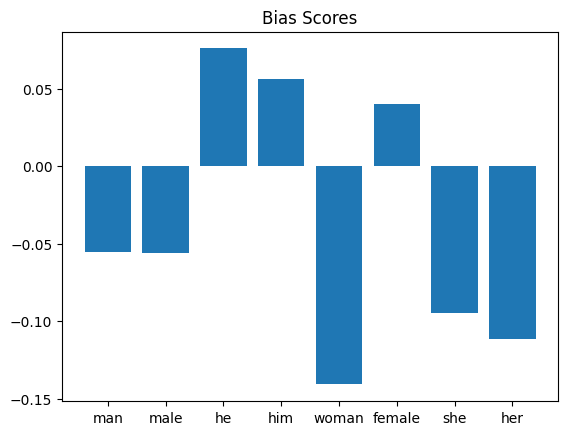

In [ ]:
import gensim.downloader as api

# Load pretrained embeddings
model = api.load("word2vec-google-news-300")  # ~1.5GB

# Target sets
X = ["man", "male", "he", "him"]
Y = ["woman", "female", "she", "her"]

# Attribute sets
A = ["career", "job", "office", "salary"]
B = ["home", "family", "children", "kitchen"]

import numpy as np

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


def association(w, A, B, model):
    w_vec = model[w]

    sim_A = np.mean([cosine_similarity(w_vec, model[a]) for a in A])
    sim_B = np.mean([cosine_similarity(w_vec, model[b]) for b in B])

    return sim_A - sim_B


def weat_score(X, Y, A, B, model):
    score_X = sum([association(x, A, B, model) for x in X])
    score_Y = sum([association(y, A, B, model) for y in Y])

    return score_X - score_Y


score = weat_score(X, Y, A, B, model)

print("WEAT Score:", score)


import random

def permutation_test(X, Y, A, B, model, iterations=1000):
    combined = X + Y
    original = weat_score(X, Y, A, B, model)

    count = 0
    for _ in range(iterations):
        random.shuffle(combined)
        X_new = combined[:len(X)]
        Y_new = combined[len(X):]

        new_score = weat_score(X_new, Y_new, A, B, model)

        if new_score > original:
            count += 1

    return count / iterations


p_value = permutation_test(X, Y, A, B, model)
print("p-value:", p_value)


import matplotlib.pyplot as plt

words = X + Y
scores = [association(w, A, B, model) for w in words]

plt.bar(words, scores)
plt.title("Bias Scores")
plt.show()